## Single-cell playaround

In [1]:
import sys
sys.path.append("/scratch/project_465001820/Spatialformer/data_preprocessing")
from process import KNN_Radius_Graph
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import List, Dict, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Optional
import pandas as pd
from dask.distributed import Client
import itertools
from tqdm.auto import tqdm
from dask.distributed import as_completed

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def qc(df) -> pd.DataFrame:
    """Run QC and return filtered dataframe."""
    rename_map = {}
    if "x_location" in df.columns:
        rename_map["x_location"] = "x"
    if "y_location" in df.columns:
        rename_map["y_location"] = "y"
    if "z_location" in df.columns:
        rename_map["z_location"] = "z"
    if "feature_name" in df.columns:
        rename_map["feature_name"] = "gene"
    if rename_map:
        df = df.rename(columns=rename_map)
    # print("qc df:", self.df)
    # More efficient filtering
    df_flt1 = df[
        ~(df["gene"].str.startswith("Neg") |
          df["gene"].str.startswith("BLANK") |
          df["gene"].str.startswith("Unassigned"))
    ].copy()

    # Optimized cell filtering
    vc = df_flt1["cell_id"].value_counts()
    if "UNASSIGNED" in vc.index:
        vc = vc.drop("UNASSIGNED")
    good_cells = vc[vc >= 30].index
    df_flt2 = df_flt1[df_flt1["cell_id"].isin(good_cells)].reset_index(drop=True)
    return df_flt2

loading the example data

In [3]:
current_path = "/scratch/project_465001820/Spatialformer/downstream/Coordinate_perturbation"
magic_path = lambda *x: os.path.join(os.path.abspath(current_path), *x)
df = pd.read_csv(magic_path("data", "lung_transcripts.csv.gz"), compression='gzip') 

In [4]:
df_flt = qc(df)

In [5]:
cell_id = df_flt["cell_id"].unique()[0]
all_genes = df_flt["gene"].unique()
clustering = True

In [6]:
example_df = df_flt[df_flt["cell_id"] == cell_id]

In [7]:
df_flt[df_flt["cell_id"] == cell_id].shape

(571, 10)

In [8]:
ref_genes = np.array(sorted(all_genes))

In [16]:
def gaussian_noise(df: pd.DataFrame = None, std: int = 0, iteration: int = 0) -> pd.DataFrame:
    """
    Add gaussian noise to the transcript spatial coordinates

    Args:
    df: dataframe of the transcripts.csv file
    std: the standard deviation of the perturbation, which indicates the strength of the noise.
    ==============================
    Return:
    the perturbed dataframe

    """
    perturb_df = df.copy()
    #noise level
    noise_x = np.random.normal(0, std, perturb_df.shape[0])
    noise_y = np.random.normal(0, std, perturb_df.shape[0])
    noise_z = np.random.normal(0, std, perturb_df.shape[0])

    # accumulate the noise
    if iteration == 0:
        perturb_df["x_0"] = perturb_df["x"] + noise_x
        perturb_df["y_0"] = perturb_df["y"] + noise_y
        perturb_df["z_0"] = perturb_df["z"] + noise_z
    else:
        perturb_df[f"x_{iteration}"] = perturb_df[f"x_{iteration-1}"] + noise_x
        perturb_df[f"y_{iteration}"] = perturb_df[f"y_{iteration-1}"] + noise_y
        perturb_df[f"z_{iteration}"] = perturb_df[f"z_{iteration-1}"] + noise_z
        #delete the previous columns
        cols_to_delete = [f"x_{iteration-1}", f"y_{iteration-1}", f"z_{iteration-1}"]
        perturb_df = perturb_df.drop(columns=cols_to_delete, errors="ignore")

    # print(perturb_df)
    #assign the noise back to the original coordinates
    perturb_df["x"] = perturb_df[f"x_{iteration}"]
    perturb_df["y"] = perturb_df[f"y_{iteration}"]
    perturb_df["z"] = perturb_df[f"z_{iteration}"]
    return perturb_df



def metric(gene_pair1: List, gene_pair2: List)-> float:
    """
    evaluation of the robustness

    Args:
    gene_pair1: List, the reference gene pairs that were originally detected by the actual coordinate system
    gene_pair2: List, the gene pairs that were found when the perturbed coordinates were introduced
    ============================
    Return:
    
    """
    # Convert to numpy array
    gene_pair1_arr = np.array(gene_pair1)
    gene_pair2_arr = np.array(gene_pair2)
    # Find common pairs using broadcasting
    # This creates a 3D boolean array and checks for any matches
    mask = np.any(np.all(gene_pair2_arr[:, np.newaxis] == gene_pair1_arr, axis=2), axis=1)
    rec_pairs = np.where(mask)[0]
    keep_pct = len(rec_pairs)/len(gene_pair1)
    # print(gene_pair1_arr, gene_pair2_arr, mask, rec_pairs, keep_pct)
    return keep_pct
def get_gco(gene_binary_matrix: np.ndarray, all_genes: List[str]) -> List:
    """
    Get the non-redundance gene pairs from the co-occurrence matrix

    Args:
    gene_binary_matrix: np.ndarray, the binary gene-gene co-occurrence matrix
    all_genes: List. A list with all the gene names in the dataset
    ==========
    Return:
    gene_pair: a single list that contains the paired gene pairs 
    
    """
    all_genes = list(sorted(all_genes))
    
    # Create upper triangle mask (excluding diagonal)
    upper_triangle = np.triu(gene_binary_matrix, k=1)
    
    # Find non-zero positions in upper triangle
    nonzero_rows, nonzero_cols = np.where(upper_triangle != 0)
    nonzero_values = gene_binary_matrix[nonzero_rows, nonzero_cols]
    
    gene_pair = []
    
    for row, col in zip(nonzero_rows, nonzero_cols):
        gene_pair.append([all_genes[row], all_genes[col]])
    return gene_pair

In [17]:
# getting the reference gene pairs for comparing
def get_num(r, i, df, clustering):
    data_graph = KNN_Radius_Graph(radius=r, dataset=example_df, is_3D=True, cell_ID=cell_id, ref_gene=ref_genes, clustering = clustering)
    gene_binary_matrix1, gene_freq_matrix, trans_matrix = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    num1 = gene_binary_matrix1.sum()/2
    df_noise = gaussian_noise(df = df, std = 0.2, iteration = i)
    data_graph = KNN_Radius_Graph(radius=r, dataset=df_noise, is_3D=True, cell_ID=cell_id, ref_gene=ref_genes, clustering = clustering)
    gene_binary_matrix2, gene_freq_matrix, trans_matrix = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    num2 = gene_binary_matrix2.sum()/2
    ref_gene_pairs = get_gco(gene_binary_matrix1, all_genes)
    ptb_gene_pairs = get_gco(gene_binary_matrix2, all_genes)
    pct = metric(ref_gene_pairs, ptb_gene_pairs)
    return pct, df_noise

In [14]:
c_df = df_flt
pct, df_noise = get_num(5, 0, c_df, False)

In [13]:
pct

0.7135922330097088

In [15]:
pct

0.9745547073791349

In [16]:
df_noise

,transcript_id,cell_id,overlaps_nucleus,gene,x,y,z,qv,fov_name,nucleus_distance,x_0,y_0,z_0
0,281492156579872,aaaaecib-1,0,EPAS1,429.814991,1745.460917,15.781834,21.255924,V14,5.096827,429.814991,1745.460917,15.781834
1,281492156579873,aaaaecib-1,0,S100A9,429.343040,1747.558772,19.573429,17.624393,V14,3.248569,429.343040,1747.558772,19.573429
2,281492156579875,aaaaecib-1,0,EPAS1,431.658786,1746.800878,17.679327,40.000000,V14,4.650679,431.658786,1746.800878,17.679327
3,281492156579876,aaaaechc-1,0,LPAR1,435.100293,1725.745397,17.248853,40.000000,V14,4.986408,435.100293,1725.745397,17.248853
4,281492156579878,aaaaechc-1,0,EPAS1,435.974281,1716.225372,17.485178,19.268982,V14,8.121383,435.974281,1716.225372,17.485178
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518346,281565171405635,aaaafgkf-1,0,COL1A2,3559.215136,2805.005416,21.979902,40.000000,X19,12.079834,3559.215136,2805.005416,21.979902
8518347,281565171405636,aaaafgkl-1,0,KRT8,3560.182931,2862.578716,22.176835,17.366875,X19,12.236663,3560.182931,2862.578716,22.176835
8518348,281565171405639,aaaafgkl-1,0,KRT8,3564.346662,2848.977121,22.125879,40.000000,X19,10.410830,3564.346662,2848.977121,22.125879
8518349,281565171061492,aaaafhep-1,0,ITGA3,3499.935492,3000.280150,21.672174,40.000000,X19,13.046923,3499.935492,3000.280150,21.672174


In [ ]:
rsl1 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(5, i, c_df, True)
    rsl1[i] = pct
    c_df = df_noise
    
rsl1_1 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(5, i, c_df, False)
    rsl1_1[i] = pct
    c_df = df_noise

100%|██████████| 500/500 [21:09<00:00,  2.54s/it]


In [11]:
rsl2 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(4, i, c_df, True)
    rsl2[i] = pct
    c_df = df_noise

rsl2_2 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(4, i, c_df, False)
    rsl2_2[i] = pct
    c_df = df_noise

100%|██████████| 500/500 [21:01<00:00,  2.52s/it]


In [12]:
rsl3 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(3, i, c_df, True)
    rsl3[i] = pct
    c_df = df_noise

rsl3_2 = {}
c_df = df_flt
for i in tqdm(range(500)):
    pct, df_noise = get_num(3, i, c_df, False)
    rsl3_2[i] = pct
    c_df = df_noise    

100%|██████████| 500/500 [20:59<00:00,  2.52s/it]


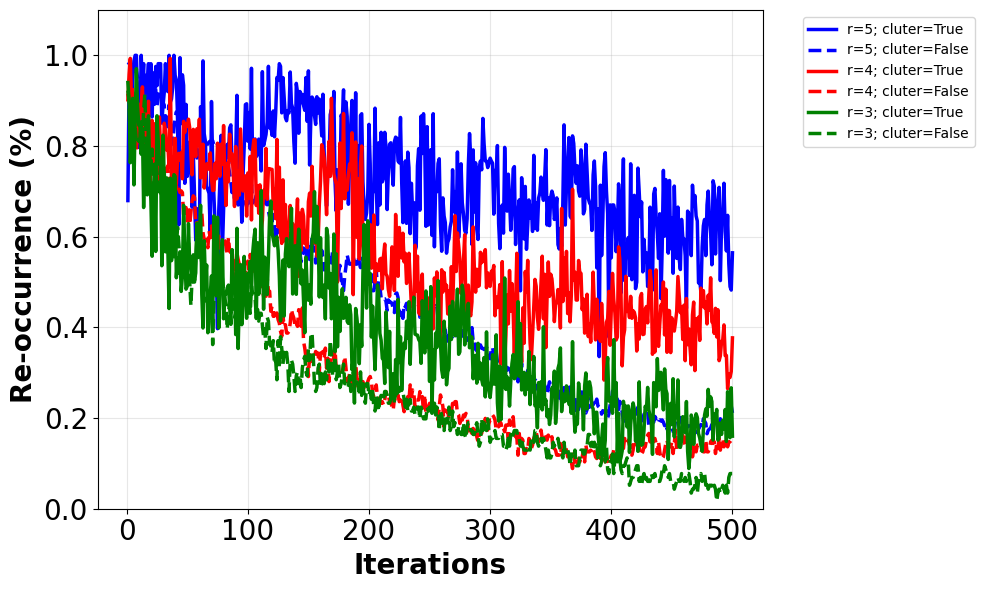

In [13]:
plt.figure(figsize=(10, 6))

# Plot shaded band (mean ± std)
df1 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl1.items()
    ])
df1_1 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl1_1.items()
    ])
df2 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl2.items()
    ])
df2_2 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl2_2.items()
    ])
df3 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl3.items()
    ])
df3_2 = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": values}
        for k, values in rsl3_2.items()
    ])
# Plot mean line
sns.lineplot(
    data=df1,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linewidth=2.5,
    markersize=8,
    color = "blue",
    label="r=5; cluter=True"
)
sns.lineplot(
    data=df1_1,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linestyle="--",
    linewidth=2.5,
    markersize=8,
    color = "blue",
    label="r=5; cluter=False"
)
sns.lineplot(
    data=df2,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linewidth=2.5,
    markersize=8,
    color = "red",
    label="r=4; cluter=True"
)
sns.lineplot(
    data=df2_2,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linestyle="--",
    linewidth=2.5,
    markersize=8,
    color = "red",
    label="r=4; cluter=False"
)
sns.lineplot(
    data=df3,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linewidth=2.5,
    markersize=8,
    color = "green",
    label="r=3; cluter=True"
)
sns.lineplot(
    data=df3_2,
    x="Iteration",
    y="Re_occurrence_rate",
    marker=None,
    linestyle="--",
    linewidth=2.5,
    markersize=8,
    color = "green",
    label="r=3; cluter=False"
)

# Labeling & aesthetics
plt.xlabel("Iterations", fontsize=20, fontweight="bold")
plt.ylabel("Re-occurrence (%)", fontsize=20, fontweight="bold")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title(title, fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
# plt.savefig(magic_path("figures", filename), dpi=300)
plt.show() 



    

In [14]:
r = 5
num = get_num(r)

TypeError: get_num() missing 3 required positional arguments: 'i', 'df', and 'clustering'

In [ ]:
num

In [ ]:
example_pairs = (ref_genes[np.where(gene_binary_matrix==1)[0][0]], ref_genes[np.where(gene_binary_matrix==1)[1][0]])

In [ ]:
example_pairs

In [ ]:
example_df = df_flt[df_flt["cell_id"] == cell_id]

In [ ]:
example_df["gene"].nunique()

In [ ]:
gene_binary_matrix.sum()/2

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(example_df["x"], example_df["y"], color='blue')
# plt.scatter(b_x, b_y, color='red', label=f'{example_pairs[1]}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of genes a and b')
plt.legend()
plt.show()

In [ ]:
a_x = example_df[example_df["gene"] == example_pairs[0]]["x"]
a_y = example_df[example_df["gene"] == example_pairs[0]]["y"]

b_x = example_df[example_df["gene"] == example_pairs[1]]["x"]
b_y = example_df[example_df["gene"] == example_pairs[1]]["y"]

In [ ]:
# Create the plot
plt.figure(figsize=(8,6))

plt.scatter(example_df["x"], example_df["y"], color='blue')
plt.scatter(a_x, a_y, color='green', label=f'{example_pairs[0]}')
plt.scatter(b_x, b_y, color='red', label=f'{example_pairs[1]}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of genes a and b')
plt.legend()
plt.show()


In [ ]:
a_x.shape

In [ ]:
example_df.shape